In [1]:
%reload_ext autoreload
%autoreload 2
import sys, os
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Add project root to path
project_root = '/sdf/group/neutrino/pgranger/larnd-sim-jax/src'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%cd /sdf/group/neutrino/pgranger/larnd-sim-jax

from larndsim.consts_jax import build_params_class, load_detector_properties, load_lut
from larndsim.losses_jax import llhd_loss, adc2charge, mse_adc
from optimize.strategies import LUTSimulation, LUTProbabilisticSimulation
from optimize.dataio import TracksDataset, DataLoader
from optimize.ranges import ranges
import optimize.strategies
import logging
logging.getLogger(optimize.strategies.__name__).setLevel(logging.WARNING)

/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/sdf/group/neutrino/pgranger/larnd-sim-jax


In [2]:
# --- Configuration ---
INPUT_FILE = '/sdf/data/neutrino/cyifan/diffsim_input/true_through_muon_edep_10cm_vol1cm.h5'
LUT_FILE = 'src/larndsim/detector_properties/response_44_v2a_full_tick.npz'
DET_PROPS = 'src/larndsim/detector_properties/module0.yaml'
PIXEL_LAYOUTS = 'src/larndsim/pixel_layouts/multi_tile_layout-2.4.16_v4.yaml'

RELEVANT_PARAMS = ['Ab', 'kb', 'lifetime', 'tran_diff', 'long_diff', 'eField', 'shift_x', 'shift_y', 'shift_z']

# Simulation Settings
ELECTRON_SAMPLING_RESOLUTION = 0.01
NUMBER_PIX_NEIGHBORS = 4
SIGNAL_LENGTH = 150

ParamsClass = build_params_class(RELEVANT_PARAMS)
ref_params = load_detector_properties(ParamsClass, DET_PROPS, PIXEL_LAYOUTS)
ref_params = ref_params.replace(
    electron_sampling_resolution=ELECTRON_SAMPLING_RESOLUTION,
    number_pix_neighbors=NUMBER_PIX_NEIGHBORS,
    signal_length=SIGNAL_LENGTH,
    time_window=SIGNAL_LENGTH,
)

try:
    response, ref_params = load_lut(LUT_FILE, ref_params)
    print("LUT loaded.")
except Exception as e:
    # fallback to old lut
    response, ref_params = load_lut('src/larndsim/detector_properties/response_44.npy', ref_params)
    print("Fallback LUT loaded.")

initial_values = {p: ranges[p]['nom'] for p in RELEVANT_PARAMS}
current_params = ref_params.replace(**initial_values)
print("Parameters initialized.")

INFO:larndsim.consts_jax:Loading response from npz file
Could not load symbol cuFuncGetName. Error: /.singularity.d/libs/libcuda.so.1: undefined symbol: cuFuncGetName


LUT loaded.
Parameters initialized.


In [3]:
# Load Data
dataset = TracksDataset(filename=INPUT_FILE, nevents=-1,
                        electron_sampling_resolution=ELECTRON_SAMPLING_RESOLUTION)
dataloader = DataLoader(dataset, batch_size=-1)
tracks_batch = dataloader[0]
track_fields = dataset.get_track_fields()

# Process first track
tracks = jax.device_put(tracks_batch.reshape(-1, len(track_fields)))
print(f"Loaded {tracks.shape[0]} tracks segments.")

INFO:optimize.dataio:-- The used simulation data includes a total track length of 3630936.6377038956 cm.
INFO:optimize.dataio:-- The number of simulation batches is 57890.


Loaded 24026 tracks segments.


In [4]:
# Initialize Strategies
stoch_strategy = LUTSimulation(response)
prob_strategy = LUTProbabilisticSimulation(response)

In [5]:
# Run Probabilistic Simulation
print("Running probabilistic simulation...")
prob_prediction = prob_strategy.predict(current_params, tracks, track_fields, 42)

unique_pixels = prob_prediction['unique_pixels']

all_tick_probs = {}
all_adcs_expected = {}

for pix_idx, target_pixel in enumerate(unique_pixels):
    if target_pixel < 0:
        continue
    all_tick_probs[int(target_pixel)] = jnp.exp(prob_prediction['hit_prob'][pix_idx, 0, :])
    all_adcs_expected[int(target_pixel)] = prob_prediction['adcs_distrib'][pix_idx, 0, :]

print(f"Stored probabilistic expected distributions for {len(all_tick_probs)} valid pixels.")

Running probabilistic simulation...


/usr/local/lib/python3.10/dist-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/sdf/group/neutrino/pgranger/larnd-sim-jax/src/larndsim/detsim_jax.py:274: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in array is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.where(outside, jnp.array(-1, dtype=jnp.int64), pid)


Stored probabilistic expected distributions for 94 valid pixels.


In [6]:
# Run Stochastic Simulation Multiple Times (Optimized with Chunked JAX vmap)
from larndsim.fee_jax import get_adc_values, digitize

N_RUNS = 50000
CHUNK_SIZE = 200  # Process in chunks to prevent memory blow-up
print(f"Running stochastic simulation {N_RUNS} times using chunked JAX vmap...")

# Extract the waveforms that were already simulated
wfs = prob_prediction['wfs']
unique_pixels = prob_prediction['unique_pixels']

# Generate random keys for each run
keys = jax.random.split(jax.random.PRNGKey(42), N_RUNS)

@jax.jit
def run_chunk_stochastic(keys_chunk):
    # Vectorize the stochastic ADC generation over a chunk of random seeds
    vmap_get_adc = jax.vmap(get_adc_values, in_axes=(None, None, 0))
    integrals, ticks = vmap_get_adc(current_params, wfs, keys_chunk)
    
    # Digitize is element-wise, so we just pass the whole array
    adcs = digitize(current_params, integrals)
    
    # We only care about the FIRST hit for each pixel (index 0 along the hits axis)
    first_ticks = ticks[:, :, 0] # Shape: (CHUNK_SIZE, Npix)
    first_adcs = adcs[:, :, 0]   # Shape: (CHUNK_SIZE, Npix)
    
    return first_ticks, first_adcs

all_first_ticks = []
all_first_adcs = []

# Process in chunks to save memory but still drastically reduce Python overhead
for i in tqdm(range(0, N_RUNS, CHUNK_SIZE)):
    chunk_keys = keys[i:i+CHUNK_SIZE]
    ft, fa = run_chunk_stochastic(chunk_keys)
    all_first_ticks.append(ft)
    all_first_adcs.append(fa)

first_ticks_all = jnp.concatenate(all_first_ticks, axis=0)
first_adcs_all = jnp.concatenate(all_first_adcs, axis=0)

# Format outputs into dictionaries per pixel
all_stoch_ticks = {}
all_stoch_adcs = {}

for pix_idx, p in enumerate(unique_pixels):
    p_int = int(p)
    if p_int < 0:
        continue
        
    # A valid hit must have a tick within the waveform bounds
    valid_mask = first_ticks_all[:, pix_idx] < (wfs.shape[1] - 3)
    
    all_stoch_ticks[p_int] = np.array(first_ticks_all[valid_mask, pix_idx])
    all_stoch_adcs[p_int] = np.array(first_adcs_all[valid_mask, pix_idx])

print(f"Collected stochastic samples efficiently for {len(all_stoch_ticks)} pixels.")

Running stochastic simulation 50000 times using chunked JAX vmap...


  0%|          | 0/250 [00:00<?, ?it/s]2026-04-30 23:27:31.299469: E external/xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %reduce-window.8 = f32[128,125,16]{1,0,2} reduce-window(%constant.1360, %constant.1253), window={size=1x1x16 pad=0_0x0_0x15_0}, to_apply=%region_0.362

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-04-30 23:27:34.300826: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 4.002130041s
Constant folding an instruction is taking > 1s:

  %reduce-window.8 = f32[128,125,16]{1,0,2} reduce-window(%constant.1360, %constant.1253), window={size=1x1x16

Collected stochastic samples efficiently for 94 pixels.


In [9]:
wfs_old = wfs.copy()

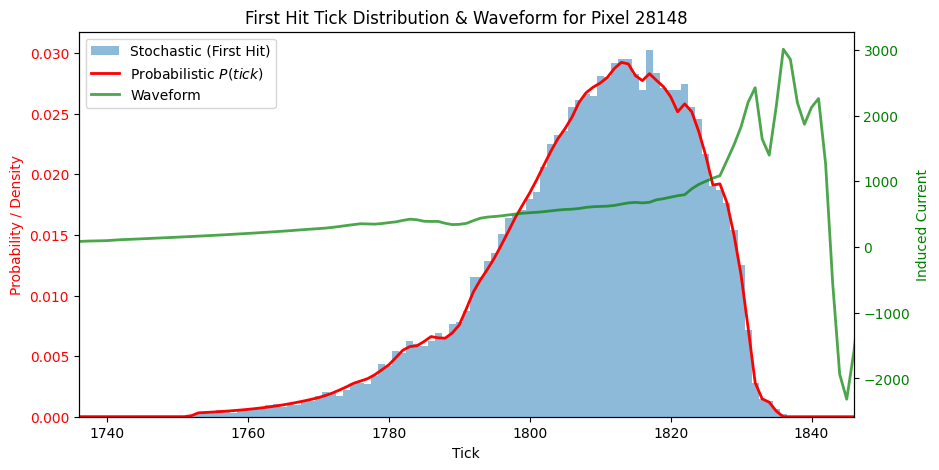

In [7]:
# Pick a pixel to plot
if len(all_tick_probs) > 0:
    target_pixel = list(all_tick_probs.keys())[2]
    
    stoch_ticks = all_stoch_ticks[target_pixel]
    tick_prob = all_tick_probs[target_pixel]

    # Plot Ticks Distribution
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.hist(stoch_ticks, bins=np.arange(0, 1999+1)-0.5, density=True, alpha=0.5, label='Stochastic (First Hit)')
    ax1.plot(np.arange(1999), tick_prob, 'r-', lw=2, label='Probabilistic $P(tick)$')
    ax1.set_xlabel('Tick')
    ax1.set_ylabel('Probability / Density', color='r')
    ax1.tick_params(axis='y', labelcolor='r')
    
    # Get the waveform for the target pixel
    pix_idx = np.where(unique_pixels == target_pixel)[0][0]
    pixel_wfs = wfs[pix_idx, :]
    
    # Create twin axis for waveform
    ax2 = ax1.twinx()
    ax2.plot(np.arange(len(pixel_wfs)), pixel_wfs, 'g-', lw=2, alpha=0.7, label='Waveform')
    ax2.set_ylabel('Induced Current', color='g')
    ax2.tick_params(axis='y', labelcolor='g')
    
    plt.title(f'First Hit Tick Distribution & Waveform for Pixel {target_pixel}')
    
    if len(stoch_ticks) > 0:
        ax1.set_xlim(max(0, np.max(stoch_ticks)-100), min(1999, np.max(stoch_ticks)+10))
        
    # Ask matplotlib for the plotted handles and labels to combine legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
    
    plt.show()
else:
    print("No valid pixels to plot!")


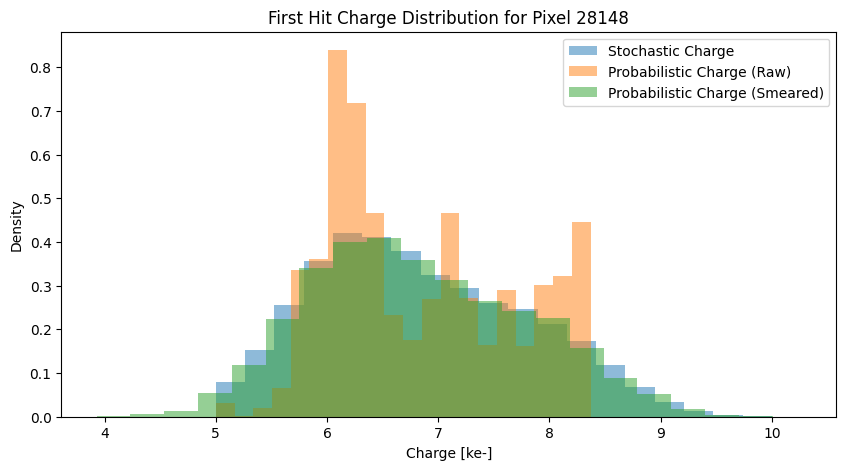

In [8]:
if len(all_tick_probs) > 0:
    stoch_adcs = all_stoch_adcs[target_pixel]
    adcs_expected = all_adcs_expected[target_pixel]

    # Convert to ke-
    stoch_charge = np.array(adc2charge(stoch_adcs, current_params))
    charge_expected = np.array(adc2charge(adcs_expected, current_params))
    noise_std_ke = current_params.UNCORRELATED_NOISE_CHARGE * 1e-3

    # Plot Charge Distribution
    plt.figure(figsize=(10, 5))
    plt.hist(stoch_charge, bins=20, density=True, alpha=0.5, label='Stochastic Charge')

    # For the probabilistic model, we sample from the expected charge and apply Gaussian smearing
    tick_prob_norm = np.array(tick_prob, dtype=np.float64)
    tick_prob_norm /= np.sum(tick_prob_norm)
    # Correct for floating-point rounding errors so the array sums EXACTLY to 1.0
    tick_prob_norm[-1] = 1.0 - np.sum(tick_prob_norm[:-1])

    sampled_ticks = np.random.choice(len(tick_prob_norm), size=10000, p=tick_prob_norm)
    sampled_charge = charge_expected[sampled_ticks]
    smeared_charge = sampled_charge + np.random.normal(0, noise_std_ke, size=10000)

    plt.hist(sampled_charge, bins=20, density=True, alpha=0.5, label='Probabilistic Charge (Raw)')
    plt.hist(smeared_charge, bins=20, density=True, alpha=0.5, label='Probabilistic Charge (Smeared)')

    plt.xlabel('Charge [ke-]')
    plt.ylabel('Density')
    plt.title(f'First Hit Charge Distribution for Pixel {target_pixel}')
    plt.legend()
    plt.show()

## Debugging: Global Hit-Rate Bias
Compare $\lambda_{\text{prob}} = \sum_t P(t)$ (the total predicted hit probability per pixel) against the empirical hit frequency from the stochastic runs.

Pixels compared : 94
Mean λ_prob     : 0.9666
Mean emp rate   : 0.9488
Mean bias (λ-emp): 0.0178  (+ = prob over-estimates, - = under-estimates)
Std  bias       : 0.0260


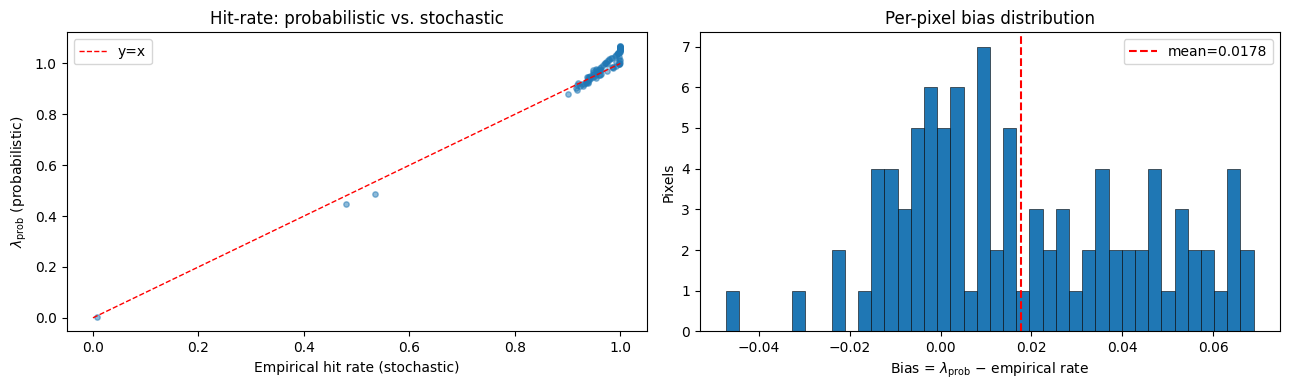

In [9]:
# --- Cell A: Global hit-rate bias (λ_prob vs empirical hit frequency) ---
# For each pixel: λ_prob = sum_t P(t|pix, hit_slot=0)
# empirical_rate = fraction of stochastic runs that produced a hit

common_pixels = sorted(set(all_tick_probs.keys()) & set(all_stoch_ticks.keys()))

lambda_prob   = np.array([float(jnp.sum(all_tick_probs[p]))     for p in common_pixels])
emp_rate      = np.array([len(all_stoch_ticks[p]) / N_RUNS       for p in common_pixels])
bias          = lambda_prob - emp_rate

print(f"Pixels compared : {len(common_pixels)}")
print(f"Mean λ_prob     : {lambda_prob.mean():.4f}")
print(f"Mean emp rate   : {emp_rate.mean():.4f}")
print(f"Mean bias (λ-emp): {bias.mean():.4f}  (+ = prob over-estimates, - = under-estimates)")
print(f"Std  bias       : {bias.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(emp_rate, lambda_prob, s=15, alpha=0.5)
axes[0].plot([0, 1], [0, 1], 'r--', lw=1, label='y=x')
axes[0].set_xlabel('Empirical hit rate (stochastic)')
axes[0].set_ylabel(r'$\lambda_{\mathrm{prob}}$ (probabilistic)')
axes[0].set_title('Hit-rate: probabilistic vs. stochastic')
axes[0].legend()

axes[1].hist(bias, bins=40, edgecolor='k', linewidth=0.4)
axes[1].axvline(bias.mean(), color='r', linestyle='--', label=f'mean={bias.mean():.4f}')
axes[1].set_xlabel(r'Bias = $\lambda_{\mathrm{prob}}$ − empirical rate')
axes[1].set_ylabel('Pixels')
axes[1].set_title('Per-pixel bias distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## Debugging: Bias vs. Signal Strength
Is the bias systematic across all pixels or correlated with signal strength (peak waveform, hit rate, etc.)?

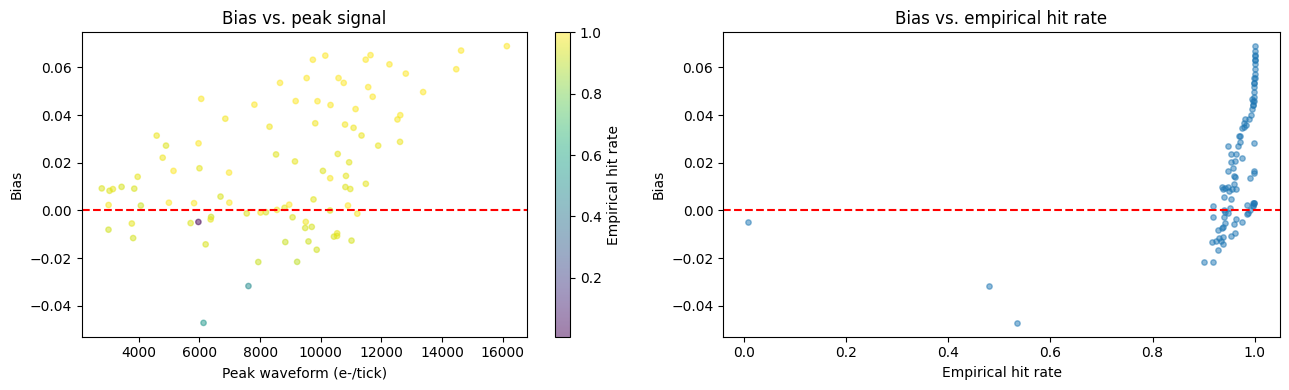

In [10]:
# --- Cell B: Bias vs. signal strength ---
wfs_for_common = []
for p in common_pixels:
    pidx = int(jnp.argmax(prob_prediction['unique_pixels'] == p))
    wfs_for_common.append(float(jnp.max(wfs[pidx])))

peak_wfs = np.array(wfs_for_common)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sc = axes[0].scatter(peak_wfs, bias, s=15, alpha=0.5, c=emp_rate, cmap='viridis')
plt.colorbar(sc, ax=axes[0], label='Empirical hit rate')
axes[0].axhline(0, color='r', linestyle='--')
axes[0].set_xlabel('Peak waveform (e-/tick)')
axes[0].set_ylabel('Bias')
axes[0].set_title('Bias vs. peak signal')

axes[1].scatter(emp_rate, bias, s=15, alpha=0.5)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Empirical hit rate')
axes[1].set_ylabel('Bias')
axes[1].set_title('Bias vs. empirical hit rate')

plt.tight_layout()
plt.show()

## Debugging: Per-Pixel Tick Distribution Overlay (Multiple Pixels)
Quick grid-view of tick distributions for a set of pixels to spot systematic timing shifts.

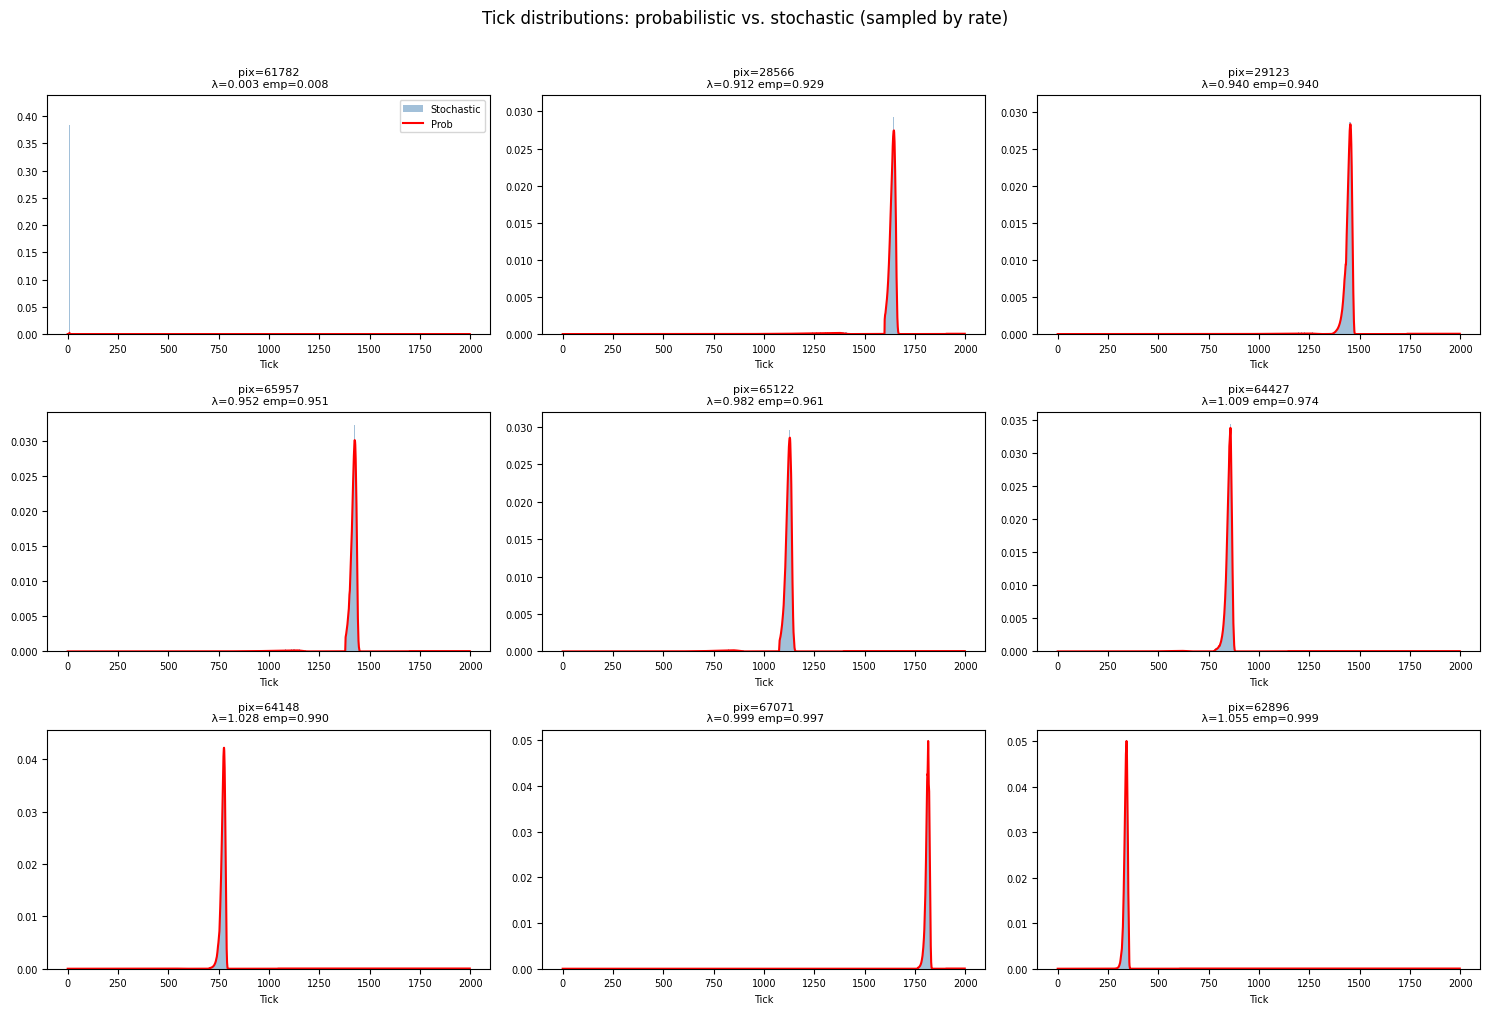

In [11]:
# --- Cell C: Grid of tick distributions for multiple pixels ---
N_SHOW = min(9, len(common_pixels))
# Pick pixels spanning a range of empirical rates
sorted_by_rate = sorted(common_pixels, key=lambda p: emp_rate[common_pixels.index(p)])
show_pixels = [sorted_by_rate[i * (len(sorted_by_rate) // N_SHOW)] for i in range(N_SHOW)]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, p in zip(axes.flat, show_pixels):
    pidx = common_pixels.index(p)
    t_prob = np.array(all_tick_probs[p])
    t_stoch = all_stoch_ticks[p]
    ticks = np.arange(len(t_prob))

    if len(t_stoch) > 0:
        ax.hist(t_stoch, bins=np.arange(len(t_prob)+1)-0.5, density=True,
                alpha=0.5, color='steelblue', label='Stochastic')
    ax.plot(ticks, t_prob, 'r-', lw=1.5, label='Prob')
    ax.set_title(f'pix={p}\n λ={lambda_prob[pidx]:.3f} emp={emp_rate[pidx]:.3f}', fontsize=8)
    ax.set_xlabel('Tick', fontsize=7)
    ax.tick_params(labelsize=7)

axes.flat[0].legend(fontsize=7)
plt.suptitle('Tick distributions: probabilistic vs. stochastic (sampled by rate)', y=1.01)
plt.tight_layout()
plt.show()

## Debugging: ADC / Charge Bias
For matched hits (same tick window), compare the expected ADC from the probabilistic model against the stochastic ADC distribution.

Matched hit pairs : 4,459,514
Mean ΔQ (prob−stoch) [ke-]: -0.0304
Std  ΔQ              [ke-]: 0.5087


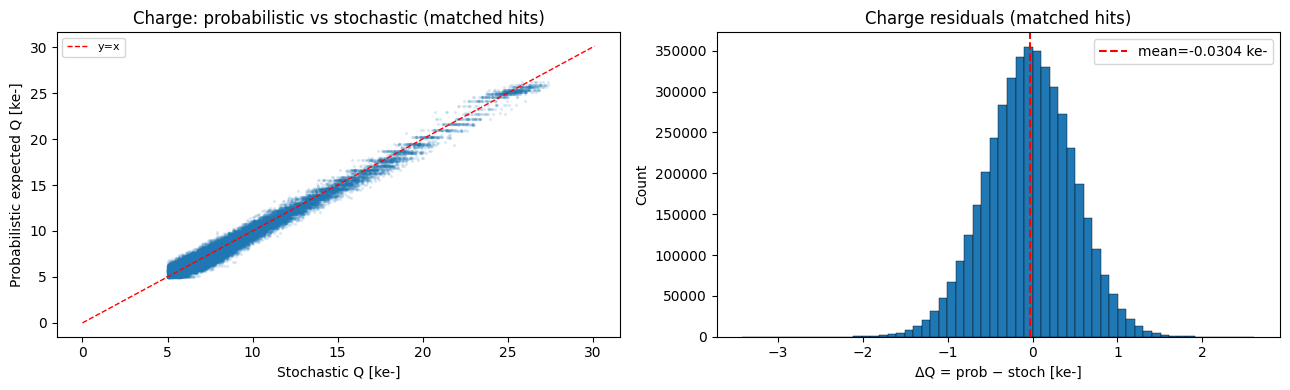

In [12]:
# --- Cell D: ADC/charge bias (matched hits within ±TICK_TOL ticks) ---
# Fully vectorised: all operations are batched over (N_RUNS, N_pix) simultaneously.
# Uses first_ticks_all / first_adcs_all (N_RUNS, N_pix) from cell 5 directly.
TICK_TOL = 2   # half-window in ticks

# ── 1. Build dense pixel-indexed matrices (N_pix_common, N_ticks) ──────────────
# Map common_pixels → column index in first_ticks_all
pix_arr    = np.array(list(prob_prediction['unique_pixels']))  # ordered as in simulation
Nticks     = wfs.shape[1]

# t_prob_mat[i, t]  = P(tick=t | pixel i, hit-slot 0)     (N_pix, Nticks)
# a_exp_mat[i, t]   = expected ADC at tick t for pixel i   (N_pix, Nticks)
valid_pix_mask = pix_arr >= 0
N_pix_sim = int(valid_pix_mask.sum())

t_prob_mat = np.array(jnp.exp(prob_prediction['hit_prob'][:, 0, :]))  # (N_pix_sim_padded, Nticks)
a_exp_mat  = np.array(prob_prediction['adcs_distrib'][:, 0, :])

# Restrict to valid (non-padding) pixels
valid_indices = np.where(valid_pix_mask)[0]                # indices into simulation arrays
t_prob_mat = t_prob_mat[valid_indices]                     # (N_pix_sim, Nticks)
a_exp_mat  = a_exp_mat[valid_indices]                      # (N_pix_sim, Nticks)
valid_pix_ids = pix_arr[valid_indices]                     # pixel IDs in order

# Map common_pixels → their index in valid_pix_ids
common_pix_arr = np.array(common_pixels)
pix_to_col = {int(p): col for col, p in enumerate(valid_pix_ids)}
col_indices = np.array([pix_to_col[p] for p in common_pixels])  # (N_common,)

# ── 2. Slice first_ticks_all / first_adcs_all to common pixels ─────────────────
# first_ticks_all: (N_RUNS, N_pix_sim_padded) — columns ordered as unique_pixels
# We need to map col_indices back to the padded array columns
padded_pix_ids = list(prob_prediction['unique_pixels'])
padded_col = np.array([padded_pix_ids.index(p) for p in common_pixels])  # (N_common,)

stoch_ticks_mat = np.array(first_ticks_all[:, padded_col])   # (N_RUNS, N_common)
stoch_adcs_mat  = np.array(first_adcs_all[:, padded_col])    # (N_RUNS, N_common)
Nticks_wf = wfs.shape[1]

# Valid stochastic hit: tick within waveform bounds
valid_hit = stoch_ticks_mat < (Nticks_wf - 3)               # (N_RUNS, N_common)

# ── 3. Build window tick indices (N_RUNS, N_common, 2*TICK_TOL+1) ──────────────
W = 2 * TICK_TOL + 1
delta = np.arange(-TICK_TOL, TICK_TOL + 1)                  # (W,)
# window_ticks[r, p, w] = stoch_ticks_mat[r, p] + delta[w], clipped to [0, Nticks-1]
window_ticks = np.clip(
    stoch_ticks_mat[:, :, None] + delta[None, None, :],
    0, Nticks - 2
).astype(int)   # (N_RUNS, N_common, W)

# ── 4. Gather t_prob and a_exp at window ticks ─────────────────────────────────
# t_prob_mat[col_indices[p], window_ticks[r, p, w]]
# We broadcast using advanced indexing over the pixel dimension
col_idx_bcast = col_indices[None, :, None]                  # (1, N_common, 1)
window_probs  = t_prob_mat[col_idx_bcast, window_ticks]     # (N_RUNS, N_common, W)
window_adcs   = a_exp_mat[col_idx_bcast, window_ticks]      # (N_RUNS, N_common, W)

# ── 5. Weighted-average expected ADC over window ────────────────────────────────
w_sum = window_probs.sum(axis=-1)                            # (N_RUNS, N_common)
safe_w_sum = np.where(w_sum > 1e-12, w_sum, 1.0)
prob_adc_matched = (window_probs * window_adcs).sum(axis=-1) / safe_w_sum  # (N_RUNS, N_common)

# ── 6. Flatten and filter to valid hits with non-zero weight ───────────────────
flat_valid  = valid_hit.ravel() & (w_sum.ravel() > 1e-12)
stoch_adc_flat = stoch_adcs_mat.ravel()[flat_valid]
prob_adc_flat  = prob_adc_matched.ravel()[flat_valid]

# Convert ADC → charge [ke-]
stoch_q = np.array(adc2charge(stoch_adc_flat, current_params))
prob_q  = np.array(adc2charge(prob_adc_flat,  current_params))
dq      = prob_q - stoch_q

print(f"Matched hit pairs : {len(dq):,}")
print(f"Mean ΔQ (prob−stoch) [ke-]: {dq.mean():.4f}")
print(f"Std  ΔQ              [ke-]: {dq.std():.4f}")

# ── 7. Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

lim = max(np.abs(stoch_q).max(), np.abs(prob_q).max()) * 1.05
# Subsample for the scatter plot to avoid over-plotting
rng = np.random.default_rng(0)
plot_idx = rng.choice(len(dq), size=min(50_000, len(dq)), replace=False)
axes[0].scatter(stoch_q[plot_idx], prob_q[plot_idx], s=2, alpha=0.10)
axes[0].plot([0, lim], [0, lim], 'r--', lw=1, label='y=x')
axes[0].set_xlabel('Stochastic Q [ke-]')
axes[0].set_ylabel('Probabilistic expected Q [ke-]')
axes[0].set_title('Charge: probabilistic vs stochastic (matched hits)')
axes[0].legend(fontsize=8)

axes[1].hist(dq, bins=60, edgecolor='k', linewidth=0.3)
axes[1].axvline(dq.mean(), color='r', linestyle='--',
                label=f'mean={dq.mean():.4f} ke-')
axes[1].set_xlabel('ΔQ = prob − stoch [ke-]')
axes[1].set_ylabel('Count')
axes[1].set_title('Charge residuals (matched hits)')
axes[1].legend()

plt.tight_layout()
plt.show()


## Debugging: Deep-Dive into a Single Pixel
For one selected pixel, plot the raw waveform, the cumulative charge, the probabilistic tick distribution, and overlay the stochastic hit times — all in one view to diagnose timing and ADC discrepancies at the FEE level.

Debugging pixel 61921  |bias|=0.0689


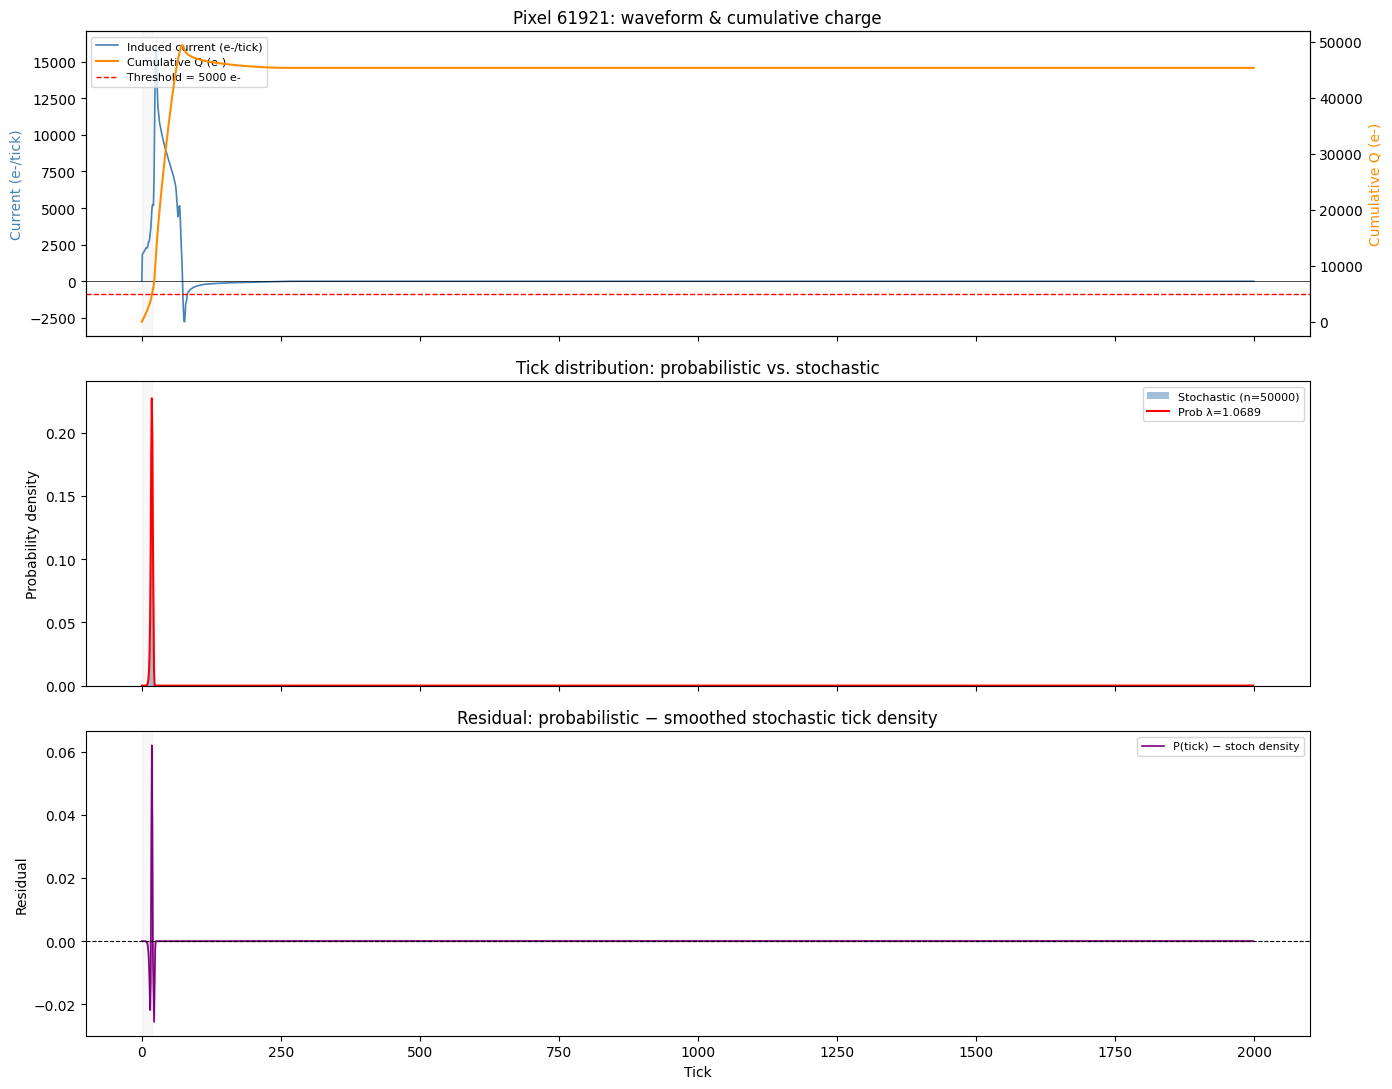


FEE parameters for pixel 61921:
  DISCRIMINATION_THRESHOLD : 5000.0 e-
  RESET_NOISE_CHARGE       : 900.0 e-
  UNCORRELATED_NOISE_CHARGE: 500.0 e-
  Integration interval     : 18 ticks
  t_sampling               : 1.000e-01 s
  Empirical hit rate       : 1.0000
  Probabilistic λ          : 1.0689
  Bias (λ − emp)           : 0.0689


In [13]:
# --- Cell E: Deep single-pixel FEE debug ---
# Choose the pixel with the largest |bias|
bias_arr = np.abs(np.array([lambda_prob[i] - emp_rate[i] for i in range(len(common_pixels))]))
debug_pixel = common_pixels[int(np.argmax(bias_arr))]
print(f"Debugging pixel {debug_pixel}  |bias|={bias_arr.max():.4f}")

pidx = int(jnp.where(prob_prediction['unique_pixels'] == debug_pixel)[0][0])
wf    = np.array(wfs[pidx])                      # induced current (e-/tick)
q_cum = np.cumsum(wf * float(current_params.t_sampling))  # cumulative charge (e-)
ticks_ax = np.arange(len(wf))

t_prob_full = np.array(all_tick_probs[debug_pixel])  # P(tick) for hit-slot 0
t_stoch     = all_stoch_ticks[debug_pixel]
interval = round((3*current_params.CLOCK_CYCLE + current_params.ADC_HOLD_DELAY*current_params.CLOCK_CYCLE) / current_params.t_sampling)

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# --- Top: waveform + cumulative charge ---
ax = axes[0]
ax.plot(ticks_ax, wf, color='steelblue', lw=1.2, label='Induced current (e-/tick)')
ax.axhline(0, color='k', lw=0.5)
ax2 = ax.twinx()
ax2.plot(ticks_ax, q_cum, color='darkorange', lw=1.5, label='Cumulative Q (e-)')
ax2.axhline(current_params.DISCRIMINATION_THRESHOLD, color='red', lw=1,
            linestyle='--', label=f'Threshold = {current_params.DISCRIMINATION_THRESHOLD:.0f} e-')
ax.set_ylabel('Current (e-/tick)', color='steelblue')
ax2.set_ylabel('Cumulative Q (e-)', color='darkorange')
lines_a, labs_a = ax.get_legend_handles_labels()
lines_b, labs_b = ax2.get_legend_handles_labels()
ax.legend(lines_a + lines_b, labs_a + labs_b, fontsize=8, loc='upper left')
ax.set_title(f'Pixel {debug_pixel}: waveform & cumulative charge')

# --- Middle: probabilistic P(tick) + stochastic histogram ---
ax = axes[1]
if len(t_stoch) > 0:
    ax.hist(t_stoch, bins=np.arange(len(wf)+1)-0.5, density=True,
            alpha=0.5, color='steelblue', label=f'Stochastic (n={len(t_stoch)})')
ax.plot(ticks_ax[:len(t_prob_full)], t_prob_full, 'r-', lw=1.5,
        label=f'Prob λ={t_prob_full.sum():.4f}')
ax.axvline(0, alpha=0)  # force x-axis sharing
ax.set_ylabel('Probability density')
ax.legend(fontsize=8)
ax.set_title('Tick distribution: probabilistic vs. stochastic')

# --- Bottom: residual P(tick) - stoch_density and ADC comparison ---
ax = axes[2]
if len(t_stoch) > 0:
    stoch_hist, bin_edges = np.histogram(t_stoch, bins=np.arange(len(wf)+1)-0.5, density=True)
    # Smooth stochastic histogram with a rolling mean to reduce noise
    from scipy.ndimage import uniform_filter1d
    stoch_smooth = uniform_filter1d(stoch_hist, size=5)
    residual = t_prob_full[:len(stoch_smooth)] - stoch_smooth[:-1]
    ax.plot(ticks_ax[:len(residual)], residual, color='purple', lw=1.2, label='P(tick) − stoch density')
    ax.fill_between(ticks_ax[:len(residual)], residual, alpha=0.2, color='purple')
ax.axhline(0, color='k', lw=0.8, linestyle='--')
ax.set_ylabel('Residual')
ax.set_xlabel('Tick')
ax.legend(fontsize=8)
ax.set_title('Residual: probabilistic − smoothed stochastic tick density')

# Highlight the integration window end on all panels
for ax_ in axes:
    ax_.axvspan(0, interval, alpha=0.05, color='gray', label=f'dead interval ({interval} ticks)')

plt.tight_layout()
plt.show()

# Print FEE params for reference
print(f"\nFEE parameters for pixel {debug_pixel}:")
print(f"  DISCRIMINATION_THRESHOLD : {current_params.DISCRIMINATION_THRESHOLD:.1f} e-")
print(f"  RESET_NOISE_CHARGE       : {current_params.RESET_NOISE_CHARGE:.1f} e-")
print(f"  UNCORRELATED_NOISE_CHARGE: {current_params.UNCORRELATED_NOISE_CHARGE:.1f} e-")
print(f"  Integration interval     : {interval} ticks")
print(f"  t_sampling               : {current_params.t_sampling:.3e} s")
print(f"  Empirical hit rate       : {len(t_stoch)/N_RUNS:.4f}")
print(f"  Probabilistic λ          : {t_prob_full.sum():.4f}")
print(f"  Bias (λ − emp)           : {t_prob_full.sum() - len(t_stoch)/N_RUNS:.4f}")

## Debugging: `q_sum_loc` vs. Stochastic ADC — What Does the Correction Actually Act On?
Trace exactly what quantity enters the secondary ADC correction in the probabilistic model vs. the stochastic model, for the selected debug pixel.

/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


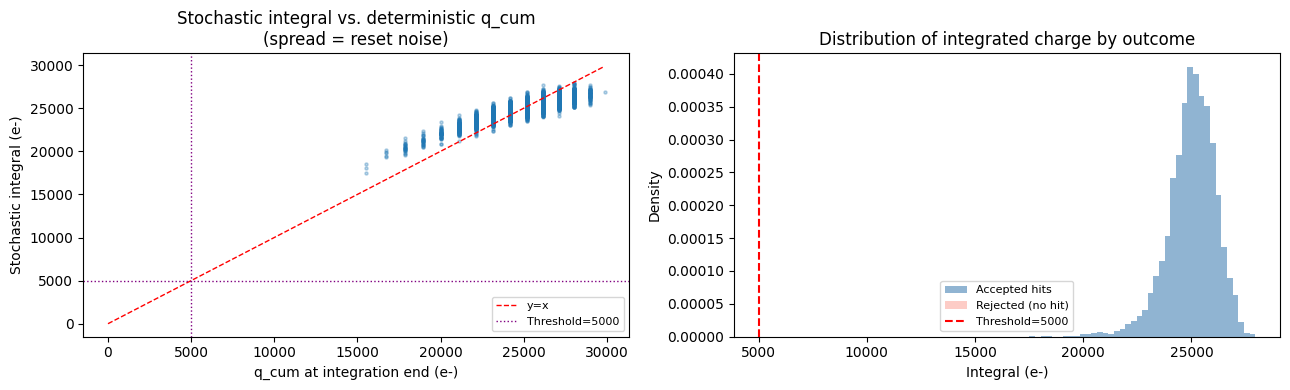


Of 5000 runs:
  Valid hits (tick < Nticks-3): 5000 (100.0%)
  Mean integral (accepted)    : 25003.3 e-
  Mean q_cum at end (det.)    : 25018.0 e-
  Difference (integral-q_cum) : -14.7 e-  ← should ≈ reset noise
  δ = Φ(Δq/σ_u) using delta_q : 1.0000
  δ = Φ((ADC-Θ)/σ_u) abs_adc : 1.0000


In [14]:
# --- Cell F: FEE internals trace for the debug pixel ---
# Reconstruct q_sum_loc (the beam-search state) and compare against
# the stochastic q_sum to understand what the secondary correction sees.

from larndsim.fee_jax import get_adc_values, digitize

pidx = int(jnp.where(prob_prediction['unique_pixels'] == debug_pixel)[0][0])
wf_single = wfs[pidx:pidx+1]   # shape (1, Nticks)

# Stochastic: collect all ADC and raw q_vals for this pixel over many runs
N_TRACE = 5000
trace_keys = jax.random.split(jax.random.PRNGKey(99), N_TRACE)

@jax.jit
def trace_single_pixel(keys_chunk):
    vmap_fn = jax.vmap(get_adc_values, in_axes=(None, None, 0))
    integrals, ticks = vmap_fn(current_params, wf_single, keys_chunk)
    adcs = digitize(current_params, integrals)
    return integrals[:, 0, 0], ticks[:, 0, 0], adcs[:, 0, 0]  # first hit, first pixel

all_integrals, all_ticks_trace, all_adcs_trace = [], [], []
CHUNK = 200
for i in range(0, N_TRACE, CHUNK):
    chunk = trace_keys[i:i+CHUNK]
    ig, tk, ad = trace_single_pixel(chunk)
    all_integrals.append(ig); all_ticks_trace.append(tk); all_adcs_trace.append(ad)

integrals_np = np.array(jnp.concatenate(all_integrals))
ticks_np     = np.array(jnp.concatenate(all_ticks_trace))
adcs_np      = np.array(jnp.concatenate(all_adcs_trace))

valid_mask = ticks_np < (wf_single.shape[1] - 3)
q_cum_single = np.cumsum(np.array(wf_single[0]) * float(current_params.t_sampling))
threshold    = float(current_params.DISCRIMINATION_THRESHOLD)

# For valid hits: integral ≈ q_cum[tick + interval + 1] (plus reset noise)
# Compare the probabilistic q_sum_loc[shifted_tick] = q_cum[tick+interval+1] - q_cum[prev_reset]
# For first hit, prev_reset = 0, so q_sum_loc == q_cum
interval = round((3*current_params.CLOCK_CYCLE + current_params.ADC_HOLD_DELAY*current_params.CLOCK_CYCLE) / current_params.t_sampling)
end_ticks = np.clip(ticks_np[valid_mask] + interval + 1, 0, len(q_cum_single)-1).astype(int)
q_at_end_expected = q_cum_single[end_ticks]
delta_q_expected  = q_at_end_expected   # for first hit, this equals q_sum_loc[shifted]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: stochastic integral vs. q_cum at integration endpoint
axes[0].scatter(q_at_end_expected, integrals_np[valid_mask], s=5, alpha=0.3)
axes[0].plot([0, q_at_end_expected.max()], [0, q_at_end_expected.max()], 'r--', lw=1, label='y=x')
axes[0].axhline(threshold, color='purple', linestyle=':', lw=1, label=f'Threshold={threshold:.0f}')
axes[0].axvline(threshold, color='purple', linestyle=':', lw=1)
axes[0].set_xlabel('q_cum at integration end (e-)')
axes[0].set_ylabel('Stochastic integral (e-)')
axes[0].set_title('Stochastic integral vs. deterministic q_cum\n(spread = reset noise)')
axes[0].legend(fontsize=8)

# Right: distribution of integrals for accepted vs. rejected hits
axes[1].hist(integrals_np[valid_mask], bins=40, density=True, alpha=0.6, label='Accepted hits', color='steelblue')
axes[1].hist(integrals_np[~valid_mask], bins=40, density=True, alpha=0.4, label='Rejected (no hit)', color='salmon')
axes[1].axvline(threshold, color='r', linestyle='--', label=f'Threshold={threshold:.0f}')
axes[1].set_xlabel('Integral (e-)')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of integrated charge by outcome')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nOf {N_TRACE} runs:")
print(f"  Valid hits (tick < Nticks-3): {valid_mask.sum()} ({100*valid_mask.mean():.1f}%)")
print(f"  Mean integral (accepted)    : {integrals_np[valid_mask].mean():.1f} e-")
print(f"  Mean q_cum at end (det.)    : {q_at_end_expected.mean():.1f} e-")
print(f"  Difference (integral-q_cum) : {(integrals_np[valid_mask] - q_at_end_expected).mean():.1f} e-  ← should ≈ reset noise")
print(f"  δ = Φ(Δq/σ_u) using delta_q : {np.mean(jax.scipy.special.ndtr(delta_q_expected/current_params.UNCORRELATED_NOISE_CHARGE)):.4f}")
print(f"  δ = Φ((ADC-Θ)/σ_u) abs_adc : {np.mean(jax.scipy.special.ndtr((delta_q_expected - threshold)/current_params.UNCORRELATED_NOISE_CHARGE)):.4f}")

## Formal Distribution Comparison: Stochastic vs. Probabilistic (per pixel)

For every pixel we compare the probabilistic predicted tick distribution $P_{\text{prob}}(t)$ against the empirical stochastic histogram $\hat{P}_{\text{stoch}}(t)$ using three complementary metrics:

| Metric | Formula | What it measures |
|---|---|---|
| **TVD** (Total Variation) | $\tfrac{1}{2}\sum_t|P_{\text{prob}}-\hat{P}_{\text{stoch}}|$ | Overall L1 mismatch, $\in[0,1]$ |
| **KL divergence** | $\sum_t \hat{P}_{\text{stoch}}\log\frac{\hat{P}_{\text{stoch}}}{P_{\text{prob}}}$ | Log-prob loss of the probabilistic model on stochastic data |
| **Wasserstein-1** | $\sum_t|\text{CDF}_{\text{prob}}-\text{CDF}_{\text{stoch}}|$ | Earth-mover (respects tick ordering) |

All three are computed fully vectorised over the pixel dimension using the empirical tick histogram matrix built directly from `stoch_ticks_mat`.

Pixels with ≥10 stochastic hits : 94 / 94
TVD          mean=0.0423  median=0.0350  max=0.4695
KL(stoch||p) mean=0.1135  median=0.0299  max=5.5027
Wasserstein1 mean=20.25 ticks  median=11.27  max=71.86
Mean tick shift mean=20.209 ticks  (+ = prob predicts later)


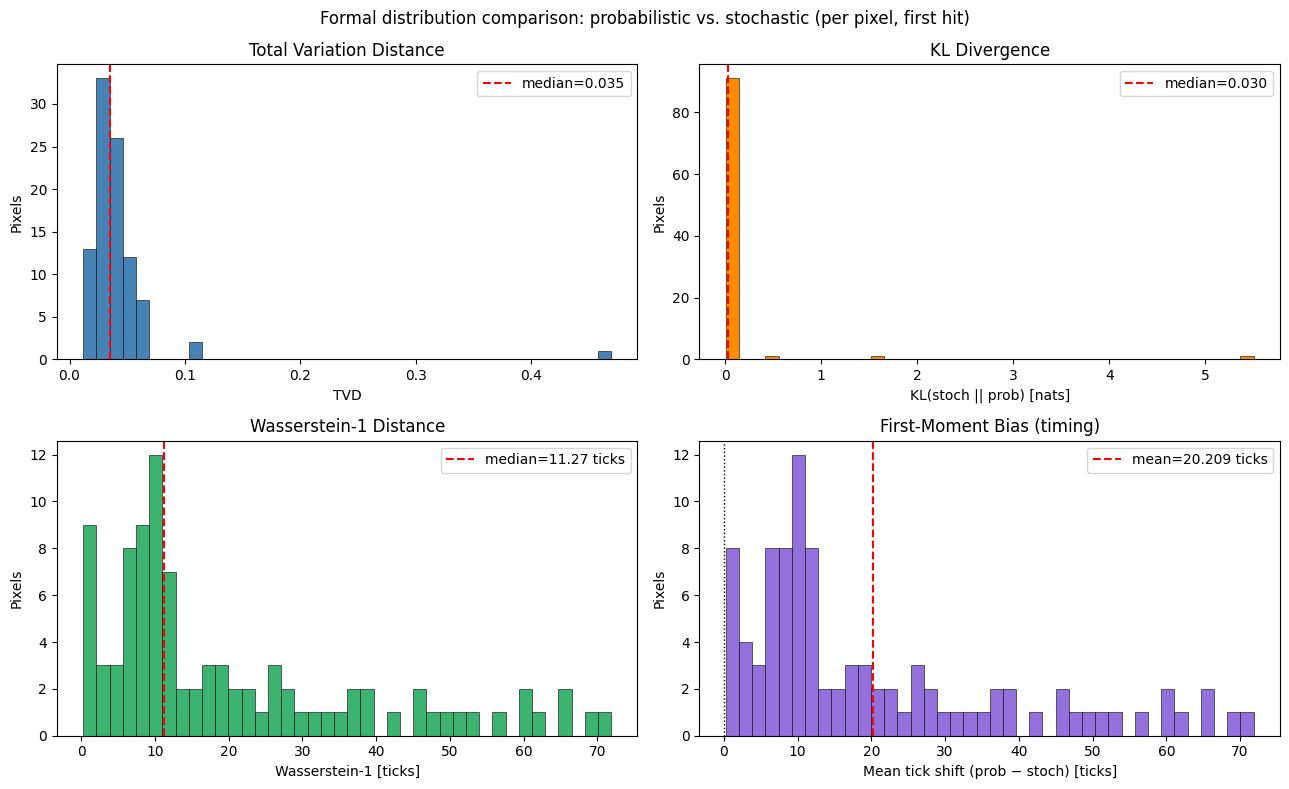


── 5 worst pixels by TVD ──
  pixel=   61782  TVD=0.4695  KL=5.5027  W1=7.26  tick_shift=5.97  emp_rate=0.008  lambda=0.003
  pixel=   62061  TVD=0.1147  KL=0.5504  W1=0.97  tick_shift=0.25  emp_rate=0.534  lambda=0.487
  pixel=   61781  TVD=0.1094  KL=1.5996  W1=3.03  tick_shift=2.65  emp_rate=0.479  lambda=0.448
  pixel=   61921  TVD=0.0645  KL=0.0668  W1=71.86  tick_shift=71.83  emp_rate=1.000  lambda=1.069
  pixel=   62060  TVD=0.0638  KL=0.0656  W1=68.67  tick_shift=68.64  emp_rate=1.000  lambda=1.067

── 5 worst pixels by Wasserstein-1 ──
  pixel=   61921  TVD=0.0645  KL=0.0668  W1=71.86  tick_shift=71.83  emp_rate=1.000  lambda=1.069
  pixel=   62060  TVD=0.0638  KL=0.0656  W1=68.67  tick_shift=68.64  emp_rate=1.000  lambda=1.067
  pixel=   62200  TVD=0.0618  KL=0.0637  W1=65.64  tick_shift=65.67  emp_rate=1.000  lambda=1.065
  pixel=   62199  TVD=0.0617  KL=0.0637  W1=64.98  tick_shift=64.94  emp_rate=1.000  lambda=1.065
  pixel=   62339  TVD=0.0602  KL=0.0620  W1=62.75  tick_

In [15]:
# --- Cell G: Formal distribution comparison metrics (TVD, KL, Wasserstein-1) ---
# Prereqs: common_pixels, col_indices, padded_col, t_prob_mat (from Cell D)
#          stoch_ticks_mat, valid_hit  (from Cell D)

# ── 1. Build stochastic empirical histogram (N_common, Nticks) ──────────────────
# The previous one-hot approach allocated (N_RUNS × N_common × Nticks) booleans
# which crashes the kernel. Replace with a per-pixel np.bincount loop:
# N_common iterations, each O(N_RUNS) in C — negligible overhead.
Nticks_hist = t_prob_mat.shape[1]
N_common = len(common_pixels)

stoch_hist_raw = np.zeros((N_common, Nticks_hist), dtype=np.float64)
for p_idx in range(N_common):
    valid_runs = valid_hit[:, p_idx]                         # (N_RUNS,) bool
    ticks_p = stoch_ticks_mat[valid_runs, p_idx].astype(np.int32)
    stoch_hist_raw[p_idx] = np.bincount(
        np.clip(ticks_p, 0, Nticks_hist - 1), minlength=Nticks_hist
    )

# Normalize: conditional distribution over ticks given a hit occurred
hit_counts = valid_hit.sum(axis=0).astype(np.float64)       # (N_common,)
safe_counts = np.where(hit_counts > 0, hit_counts, 1.0)
stoch_hist = stoch_hist_raw / safe_counts[:, None]           # (N_common, Nticks)

# Probabilistic distribution for the same pixels
t_prob_common = t_prob_mat[col_indices]                      # (N_common, Nticks)

# Normalize both to sum to 1 for conditional comparison
t_prob_norm = t_prob_common / np.maximum(t_prob_common.sum(axis=1, keepdims=True), 1e-30)
stoch_norm  = stoch_hist    / np.maximum(stoch_hist.sum(axis=1, keepdims=True),    1e-30)

# ── 2. TVD (vectorised) ─────────────────────────────────────────────────────────
tvd = 0.5 * np.abs(t_prob_norm - stoch_norm).sum(axis=1)   # (N_common,)

# ── 3. KL divergence KL(stoch || prob) (vectorised) ────────────────────────────
eps_kl = 1e-30
log_ratio = np.log(np.maximum(stoch_norm, eps_kl) / np.maximum(t_prob_norm, eps_kl))
kl = (stoch_norm * log_ratio).sum(axis=1)                   # (N_common,)
kl = np.where(hit_counts >= 10, kl, np.nan)                 # unreliable for tiny samples

# ── 4. Wasserstein-1 via CDF trick (vectorised) ─────────────────────────────────
# W1 = Σ_t |CDF_prob(t) - CDF_stoch(t)|   (discrete, equal-spaced bins → units: ticks)
cdf_prob  = np.cumsum(t_prob_norm, axis=1)
cdf_stoch = np.cumsum(stoch_norm,  axis=1)
wass1 = np.abs(cdf_prob - cdf_stoch).sum(axis=1)            # (N_common,) [ticks]
wass1 = np.where(hit_counts >= 10, wass1, np.nan)

# ── 5. Mean tick shift (first-moment bias) ──────────────────────────────────────
tick_range = np.arange(Nticks_hist, dtype=np.float64)
mean_tick_prob  = (t_prob_norm * tick_range[None, :]).sum(axis=1)
mean_tick_stoch = (stoch_norm  * tick_range[None, :]).sum(axis=1)
tick_shift = mean_tick_prob - mean_tick_stoch               # (N_common,) [ticks]
tick_shift = np.where(hit_counts >= 10, tick_shift, np.nan)

# ── 6. Summary ──────────────────────────────────────────────────────────────────
valid = np.isfinite(kl)
print(f"Pixels with ≥10 stochastic hits : {valid.sum()} / {N_common}")
print(f"TVD          mean={np.nanmean(tvd):.4f}  median={np.nanmedian(tvd):.4f}  max={np.nanmax(tvd):.4f}")
print(f"KL(stoch||p) mean={np.nanmean(kl):.4f}  median={np.nanmedian(kl):.4f}  max={np.nanmax(kl):.4f}")
print(f"Wasserstein1 mean={np.nanmean(wass1):.2f} ticks  median={np.nanmedian(wass1):.2f}  max={np.nanmax(wass1):.2f}")
print(f"Mean tick shift mean={np.nanmean(tick_shift):.3f} ticks  (+ = prob predicts later)")

# ── 7. Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].hist(tvd[valid], bins=40, edgecolor='k', linewidth=0.4, color='steelblue')
axes[0, 0].axvline(np.nanmedian(tvd), color='r', linestyle='--',
                   label=f'median={np.nanmedian(tvd):.3f}')
axes[0, 0].set_xlabel('TVD'); axes[0, 0].set_ylabel('Pixels')
axes[0, 0].set_title('Total Variation Distance'); axes[0, 0].legend()

axes[0, 1].hist(kl[valid], bins=40, edgecolor='k', linewidth=0.4, color='darkorange')
axes[0, 1].axvline(np.nanmedian(kl), color='r', linestyle='--',
                   label=f'median={np.nanmedian(kl):.3f}')
axes[0, 1].set_xlabel('KL(stoch || prob) [nats]'); axes[0, 1].set_ylabel('Pixels')
axes[0, 1].set_title('KL Divergence'); axes[0, 1].legend()

axes[1, 0].hist(wass1[valid], bins=40, edgecolor='k', linewidth=0.4, color='mediumseagreen')
axes[1, 0].axvline(np.nanmedian(wass1), color='r', linestyle='--',
                   label=f'median={np.nanmedian(wass1):.2f} ticks')
axes[1, 0].set_xlabel('Wasserstein-1 [ticks]'); axes[1, 0].set_ylabel('Pixels')
axes[1, 0].set_title('Wasserstein-1 Distance'); axes[1, 0].legend()

axes[1, 1].hist(tick_shift[valid], bins=40, edgecolor='k', linewidth=0.4, color='mediumpurple')
axes[1, 1].axvline(np.nanmean(tick_shift), color='r', linestyle='--',
                   label=f'mean={np.nanmean(tick_shift):.3f} ticks')
axes[1, 1].axvline(0, color='k', linestyle=':', lw=1)
axes[1, 1].set_xlabel('Mean tick shift (prob − stoch) [ticks]'); axes[1, 1].set_ylabel('Pixels')
axes[1, 1].set_title('First-Moment Bias (timing)'); axes[1, 1].legend()

plt.suptitle('Formal distribution comparison: probabilistic vs. stochastic (per pixel, first hit)',
             fontsize=12)
plt.tight_layout()
plt.show()

# ── 8. Worst pixels ──────────────────────────────────────────────────────────────
print("\n── 5 worst pixels by TVD ──")
for i in np.argsort(tvd)[::-1][:5]:
    p = common_pixels[i]
    print(f"  pixel={p:8d}  TVD={tvd[i]:.4f}  KL={kl[i]:.4f}  "
          f"W1={wass1[i]:.2f}  tick_shift={tick_shift[i]:.2f}  "
          f"emp_rate={emp_rate[i]:.3f}  lambda={lambda_prob[i]:.3f}")

print("\n── 5 worst pixels by Wasserstein-1 ──")
for i in np.argsort(np.where(np.isfinite(wass1), wass1, -1))[::-1][:5]:
    p = common_pixels[i]
    print(f"  pixel={p:8d}  TVD={tvd[i]:.4f}  KL={kl[i]:.4f}  "
          f"W1={wass1[i]:.2f}  tick_shift={tick_shift[i]:.2f}  "
          f"emp_rate={emp_rate[i]:.3f}  lambda={lambda_prob[i]:.3f}")


## Worst-Pixel Distribution Visualisation
Plot tick distributions for the pixels with the largest TVD and Wasserstein-1 (union of both rankings), together with the underlying waveform and cumulative charge.

In [ ]:
# --- Cell H: Distribution plots for worst pixels ---
# Prereqs: tvd, wass1, tick_shift, lambda_prob, emp_rate, common_pixels (Cell G)
#          all_tick_probs, all_stoch_ticks, wfs, prob_prediction, current_params

N_WORST = 6   # how many pixels to show

# Union of worst by TVD and worst by W1, deduped, capped at 2*N_WORST
by_tvd = list(np.argsort(tvd)[::-1][:N_WORST])
by_w1  = list(np.argsort(np.where(np.isfinite(wass1), wass1, -1))[::-1][:N_WORST])
seen, worst_indices = set(), []
for i in by_tvd + by_w1:
    if i not in seen:
        seen.add(i); worst_indices.append(i)
worst_indices = worst_indices[:N_WORST * 2]

ncols = 3
nrows = int(np.ceil(len(worst_indices) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat = np.array(axes).ravel()

for plot_idx, col_idx in enumerate(worst_indices):
    ax = axes_flat[plot_idx]
    p = common_pixels[col_idx]

    t_prob  = np.array(all_tick_probs[p])      # P(tick), un-normalised (= lambda per tick)
    t_stoch = all_stoch_ticks[p]               # stochastic first-hit ticks
    pidx    = int(jnp.where(prob_prediction['unique_pixels'] == p)[0][0])
    wf      = np.array(wfs[pidx])              # induced current
    q_cum   = np.cumsum(wf * float(current_params.t_sampling))  # cumulative charge [e-]
    ticks_ax = np.arange(len(wf))

    # Focus window around the median stochastic hit (or prob peak)
    t_center = int(np.median(t_stoch)) if len(t_stoch) > 0 else int(np.argmax(t_prob))
    hw = 60
    x_lo = max(0, t_center - hw)
    x_hi = min(len(wf) - 1, t_center + hw)

    # Stochastic histogram (density)
    if len(t_stoch) > 0:
        ax.hist(t_stoch, bins=np.arange(x_lo, x_hi + 2) - 0.5,
                density=True, alpha=0.45, color='steelblue',
                label=f'Stoch (n={len(t_stoch)})')

    # Probabilistic curve — renormalised to the display window for visual alignment
    t_prob_win = t_prob[x_lo:x_hi + 1].copy()
    win_norm = t_prob_win.sum()
    if win_norm > 1e-12:
        t_prob_win /= win_norm
    ax.plot(ticks_ax[x_lo:x_hi + 1], t_prob_win, 'r-', lw=1.5,
            label=f'Prob  λ={t_prob.sum():.3f}')

    # Cumulative charge on twin axis
    ax2 = ax.twinx()
    ax2.plot(ticks_ax[x_lo:x_hi + 1], q_cum[x_lo:x_hi + 1],
             color='darkorange', lw=1.0, alpha=0.7)
    ax2.axhline(float(current_params.DISCRIMINATION_THRESHOLD),
                color='red', lw=0.8, linestyle=':', label='Threshold')
    ax2.set_ylabel('Q_cum [e-]', fontsize=6, color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange', labelsize=6)

    ax.set_title(
        f'pix {p}\n'
        f'TVD={tvd[col_idx]:.3f}  W1={wass1[col_idx]:.1f}t  '
        f'shift={tick_shift[col_idx]:.1f}t\n'
        f'λ={lambda_prob[col_idx]:.3f}  emp={emp_rate[col_idx]:.3f}',
        fontsize=7
    )
    ax.set_xlim(x_lo, x_hi)
    ax.set_xlabel('Tick', fontsize=7)
    ax.set_ylabel('Prob density', fontsize=7)
    ax.tick_params(labelsize=6)

# Shared legend on first panel
lines1, labs1 = axes_flat[0].get_legend_handles_labels()
axes_flat[0].legend(lines1, labs1, fontsize=6, loc='upper left')

for ax in axes_flat[len(worst_indices):]:
    ax.set_visible(False)

plt.suptitle('Worst pixels: probabilistic (red) vs. stochastic histogram (blue)  —  first hit tick',
             fontsize=10)
plt.tight_layout()
plt.show()
